In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Handling Missing Values

In [2]:
import seaborn as sns 

In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
## Check missing values 
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Ways to handle missing values 

1. `Drop the datapoint that has null values`


In [5]:
## But here dropping is not the best way as we loose lot of data from 891 it only
## will be 182 left 
df.shape , df.dropna().shape

((891, 15), (182, 15))

2. `Drop the entire column which has missing values`

In [6]:
df.dropna(axis = 1).shape


(891, 11)

## Imputation of missing values 
1. `Mean value Imputation` : it works well when we have a normally distributed data or near to that which the age is the graph for that is used below 

<Axes: xlabel='age', ylabel='Count'>

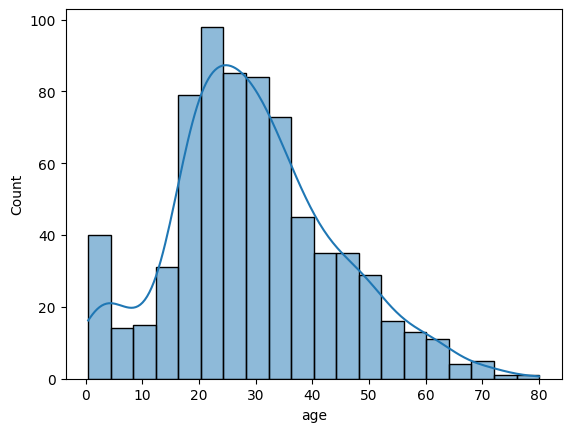

In [7]:
sns.histplot(df.age , kde = True)

The above plot looks very similar to a normal distribution so it can be a good idea to fill with mean 

In [8]:
df['age_mean'] =df['age'].fillna(df['age'].mean())

In [9]:
df[['age_mean' , 'age']]

,age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


## What if data is not normallly distributed it is right skewed or left skewed

2. `Median value imputation - if we have outliers in the dataset`

In [10]:
df['age_median'] = df['age'].fillna(df['age'].median())

In [11]:
df[['age_median' , 'age_mean' , 'age']]

,age_median,age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


3. `Mode value imputation - works well with categorical data`

In [12]:
df['embarked'].mode()[0]

'S'

In [13]:
mode_value = df[df['embarked'].notna()]['embarked'].mode()[0]

In [14]:
df['embarked_mode'] = df['embarked'].fillna(mode_value)

In [15]:
df[['embarked_mode' , 'embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [16]:
df['embarked_mode'].isnull().sum()

np.int64(0)

## Handling Imbalance Dataset 
Techniques for that 
1. `UpSampling`
2. `DownSampling`

In [17]:
import numpy as np 
import pandas as pd

np.random.seed(123)

n_samples = 1000
class_0_ratio = 0.9

n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = (n_samples - n_class_0)

In [18]:
n_class_0 , n_class_1

(900, 100)

In [19]:
## CREATE MY DATAFRAME WITH IMBALANCED DATASET
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

# Class 1: Centered around (2,2)
class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

In [20]:
df = pd.concat([class_0 , class_1]).reset_index(drop = True)

In [21]:
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [22]:
df.tail()

,feature_1,feature_2,target
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1
999,2.697490,2.013570,1


In [23]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

## Now i have made an imbalanced dataset where value 1 is only 100 and 0 is 900 the techniques to remove this :
1. `UpSampling` : increase this number of ones to 900 

In [24]:
df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

In [25]:
from sklearn.utils import resample 
df_minority_upsampled = resample(df_minority , replace = True , ##Sample with replacement
                                 n_samples = len(df_majority) , 
                                 random_state = 42
                                )

In [26]:
df_minority_upsampled.shape

(900, 3)

In [27]:
df_upsampled = pd.concat([df_majority , df_minority_upsampled])

In [28]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

## 2. Downsampling 

In [29]:
np.random.seed(123)

n_samples = 1000
class_0_ratio = 0.9

n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = (n_samples - n_class_0)

## CREATE MY DATAFRAME WITH IMBALANCED DATASET
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

# Class 1: Centered around (2,2)
class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

df['target'].value_counts()


target
0    900
1    100
Name: count, dtype: int64

In [30]:
## Downsampling 
from sklearn.utils import resample 
df_majority_downsampled = resample(df_majority , replace = False , 
                                  n_samples = len(df_minority) , 
                                  random_state = 42)

In [31]:
df_majority_downsampled.shape

(100, 3)

In [32]:
df_downsampled = pd.concat([df_minority , df_majority_downsampled])

In [33]:
df_downsampled['target'].value_counts()

target
1    100
0    100
Name: count, dtype: int64

## Handling Imbalanced Dataset using SMOTE

In [34]:
#from sklearn.imbalance import make_classification